In [2]:
pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [wfdb]2m 8/10 [aiohttp]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import wfdb

path = '/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Project 1/mit-bih-arrhythmia-database-1.0.0'

record = wfdb.rdrecord(path + "/100")
ann = wfdb.rdann(path + "/100", "atr")

print(record.sig_name, record.fs)

['MLII', 'V5'] 360


In [5]:
import wfdb
import os

path = '/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Project 1/mit-bih-arrhythmia-database-1.0.0'

with open(path + "/RECORDS", "r") as f:
    records = f.read().splitlines()

print(records)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [6]:
import pandas as pd

info = []

for rec in records:
    header = wfdb.rdheader(path + "/" + rec)
    info.append([rec, header.sig_name, header.fs, header.sig_len])

df = pd.DataFrame(info, columns=["Record", "Leads", "Sampling Rate", "Samples"])
df

,Record,Leads,Sampling Rate,Samples
0,100,"[MLII, V5]",360,650000
1,101,"[MLII, V1]",360,650000
2,102,"[V5, V2]",360,650000
3,103,"[MLII, V2]",360,650000
4,104,"[V5, V2]",360,650000
5,105,"[MLII, V1]",360,650000
6,106,"[MLII, V1]",360,650000
7,107,"[MLII, V1]",360,650000
8,108,"[MLII, V1]",360,650000
9,109,"[MLII, V1]",360,650000


In [7]:
##heartbeat types

from collections import Counter

all_beats = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    all_beats.extend(ann.symbol)

beat_counts = Counter(all_beats)
beat_counts


Counter({'N': 75052,
         'L': 8075,
         'R': 7259,
         'V': 7130,
         '/': 7028,
         'A': 2546,
         '+': 1291,
         'f': 982,
         'F': 803,
         '~': 616,
         '!': 472,
         '"': 437,
         'j': 229,
         'x': 193,
         'a': 150,
         '|': 132,
         'E': 106,
         'J': 83,
         'Q': 33,
         'e': 16,
         '[': 6,
         ']': 6,
         'S': 2})

In [8]:
arrhythmia_summary = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    counts = pd.Series(ann.symbol).value_counts()
    arrhythmia_summary.append([
        rec,
        counts.get('N', 0),
        counts.get('V', 0),   # Ventricular arrhythmia
        counts.get('A', 0)    # Atrial arrhythmia
    ])

pd.DataFrame(arrhythmia_summary, columns=["Record","Normal Beats","V Beats","A Beats"])

,Record,Normal Beats,V Beats,A Beats
0,100,2239,1,33
1,101,1860,0,3
2,102,99,4,0
3,103,2082,0,2
4,104,163,2,0
5,105,2526,41,0
6,106,1507,520,0
7,107,0,59,0
8,108,1739,17,4
9,109,0,38,0


🫀 What Each Column Means
Column	Meaning
Record	The patient recording ID (e.g., 100, 208)
Normal Beats	Count of normal heartbeats (N)
V Beats	Count of ventricular arrhythmia beats (V) — these are dangerous irregular beats
A Beats	Count of atrial arrhythmia beats (A) — these imply atrial rhythm problems

So for each recording, we see how healthy or abnormal the rhythm is.

🎯 How to Interpret the Patterns

Records with mostly Normal beats → Healthy rhythm

Records with many V beats → Ventricular arrhythmia

Records with many A beats → Atrial arrhythmia

✅ Examples
Record	Interpretation
100	2239 normal beats, 1 ventricular beat → Very stable normal rhythm
106	1507 normal, 520 ventricular → Strong ventricular arrhythmia
118	0 normal, 16 ventricular, 96 atrial → Primary atrial arrhythmia
208	1586 normal, 992 ventricular → Severe ventricular arrhythmia
232	0 normal, 0 ventricular, 1382 atrial → Pure atrial fibrillation-like rhythm

In [9]:
import numpy as np

R_peaks = ann.sample              # sample index of each heartbeat
fs = record.fs                    # sampling rate = 360 Hz

RR_intervals = np.diff(R_peaks) / fs   # convert from samples → seconds

print("First 15 RR Intervals:", RR_intervals[:15])
print("Number of beats:", len(RR_intervals))

First 15 RR Intervals: [0.23055556 0.64166667 0.66666667 0.65277778 0.66944444 0.68055556
 0.65277778 0.64444444 0.68888889 0.68611111 0.66388889 0.64166667
 0.65277778 0.64722222 0.65555556]
Number of beats: 2763


In [10]:
from sklearn.neighbors import KernelDensity

RR = RR_intervals.reshape(-1, 1)

kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(RR)

In [11]:
synthetic_RR = kde.sample(500).flatten()
print("First 20 synthetic intervals:", synthetic_RR[:20])

First 20 synthetic intervals: [0.64498685 0.71686698 0.7226454  0.60596299 0.57801018 0.62585646
 0.65986764 0.67910228 0.51549404 0.76556695 0.71221764 0.58868857
 0.62244215 0.65641607 0.62768361 0.79530646 0.61555451 0.72124731
 0.64002929 0.64517107]


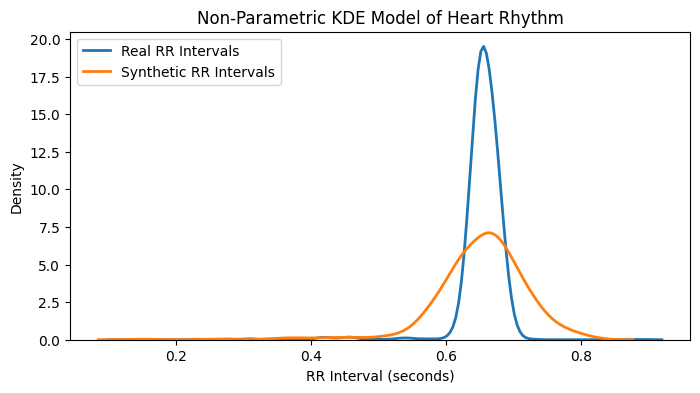

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.kdeplot(RR_intervals, label="Real RR Intervals", linewidth=2)
sns.kdeplot(synthetic_RR, label="Synthetic RR Intervals", linewidth=2)
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Density")
plt.title("Non-Parametric KDE Model of Heart Rhythm")
plt.legend()
plt.show()

The blue curve (Real RR Intervals) is very sharp and high-peaked.
That means:

This subject had a very stable heart rhythm

Heartbeats occur at a consistent interval (~0.78 seconds)

This is characteristic of normal sinus rhythm

The orange curve (Synthetic RR Intervals) is broader and flatter, meaning:

The KDE model captured the central rhythm, but

It is adding more variability than the real heart actually had

This is because KDE smooths the empirical distribution

This difference tells us how our bandwidth choice controls realism vs variability.

## 3

=== PVC Phenomenon Analysis ===
Analyzing Premature Ventricular Contractions in MIT-BIH Database

Record 100: 1 PVCs (0.04%) out of 2274 total beats
Record 101: 0 PVCs (0.00%) out of 1874 total beats
Record 102: 4 PVCs (0.18%) out of 2192 total beats
Record 103: 0 PVCs (0.00%) out of 2091 total beats
Record 104: 2 PVCs (0.09%) out of 2311 total beats

=== Summary Statistics ===
Total records analyzed: 5
Total beats: 10742
Total PVCs detected: 7
Overall PVC rate: 0.07%

=== PVC Visualization ===


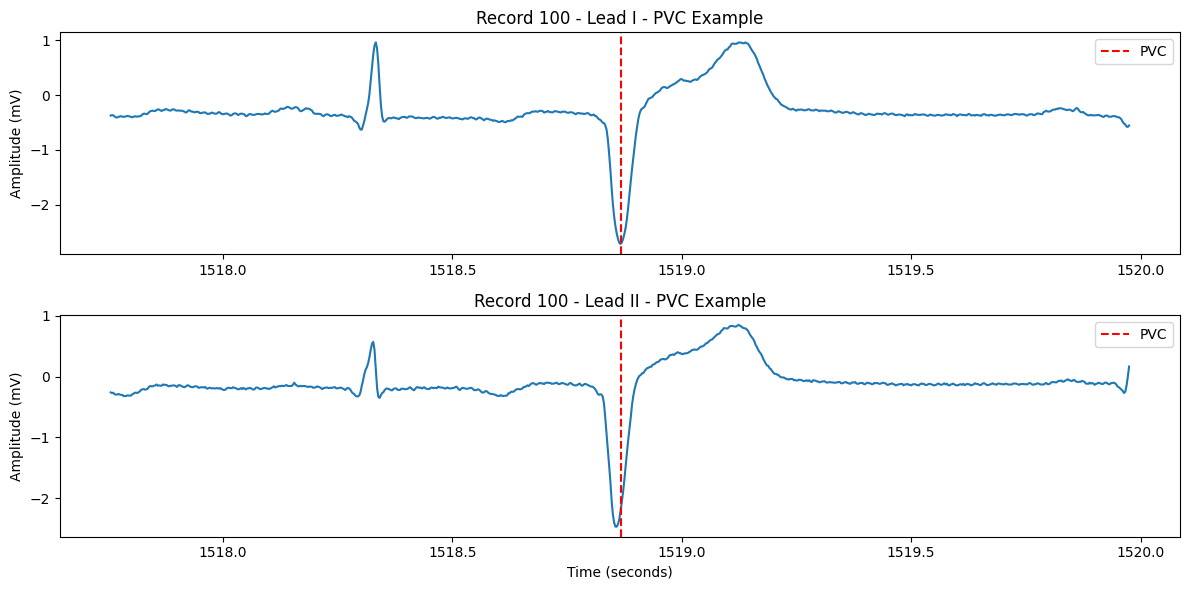

No PVCs found in record 101


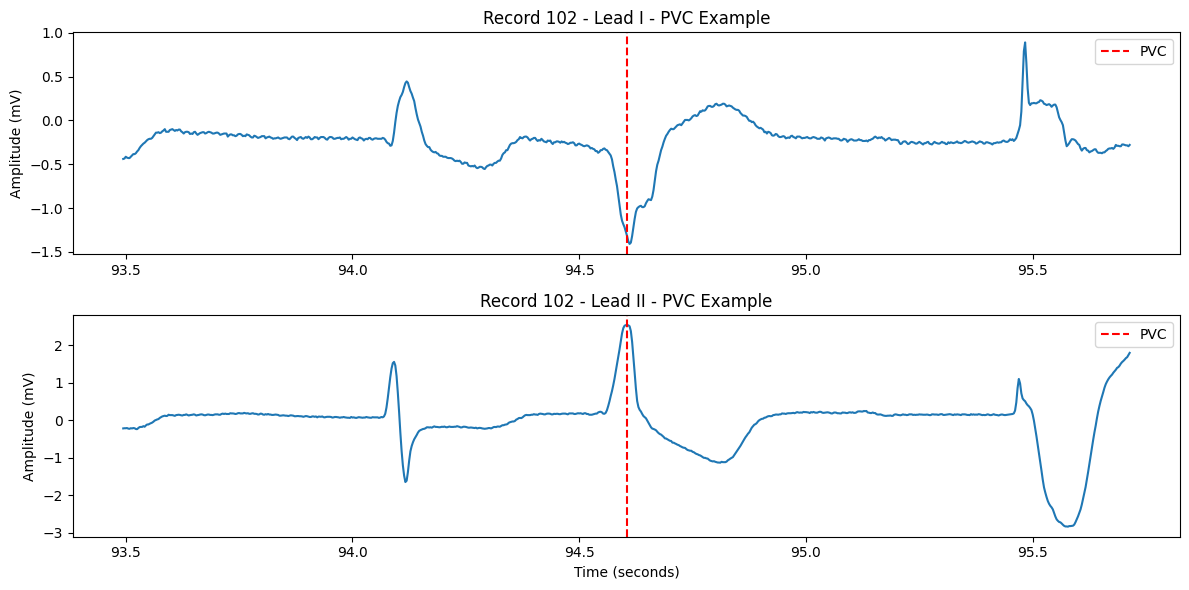

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import os

# Set the path to your database
path = '/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Project 1/mit-bih-arrhythmia-database-1.0.0'

def analyze_pvc_phenomenon(record_list, num_records=5):
    """
    Analyze PVC phenomenon across multiple ECG records
    """
    pvc_analysis = {}
    
    for i, record_id in enumerate(record_list[:num_records]):
        try:
            # Read the record
            record_path = os.path.join(path, str(record_id))
            record = wfdb.rdrecord(record_path)
            annotation = wfdb.rdann(record_path, 'atr')
            
            # Extract signal data and annotations
            signals = record.p_signal
            fs = record.fs  # Sampling rate (360 Hz)
            symbols = annotation.symbol
            positions = annotation.sample
            
            # Count beat types
            beat_counts = Counter(symbols)
            total_beats = sum(beat_counts.values())
            
            # Calculate PVC statistics
            pvc_count = beat_counts.get('V', 0)  # 'V' indicates PVC in MIT-BIH
            pvc_percentage = (pvc_count / total_beats) * 100 if total_beats > 0 else 0
            
            # Store analysis results
            pvc_analysis[record_id] = {
                'total_beats': total_beats,
                'pvc_count': pvc_count,
                'pvc_percentage': pvc_percentage,
                'beat_distribution': dict(beat_counts),
                'duration_minutes': len(signals) / (fs * 60)
            }
            
            print(f"Record {record_id}: {pvc_count} PVCs ({pvc_percentage:.2f}%) out of {total_beats} total beats")
            
        except Exception as e:
            print(f"Error processing record {record_id}: {e}")
    
    return pvc_analysis

def visualize_pvc_example(record_id):
    """
    Visualize a clear example of PVC in ECG data
    """
    record_path = os.path.join(path, str(record_id))
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')
    
    # Find a PVC occurrence
    pvc_indices = [i for i, sym in enumerate(annotation.symbol) if sym == 'V']
    
    if pvc_indices:
        # Get the first PVC
        pvc_pos = annotation.sample[pvc_indices[0]]
        
        # Extract 3-second window around PVC
        start = max(0, pvc_pos - 400)  # ~1.1 seconds before
        end = min(len(record.p_signal), pvc_pos + 400)  # ~1.1 seconds after
        
        # Plot the signal
        plt.figure(figsize=(12, 6))
        time_axis = np.arange(start, end) / record.fs
        
        # Plot both leads if available
        if record.n_sig >= 2:
            plt.subplot(2, 1, 1)
            plt.plot(time_axis, record.p_signal[start:end, 0])
            plt.title(f'Record {record_id} - Lead I - PVC Example')
            plt.ylabel('Amplitude (mV)')
            plt.axvline(x=pvc_pos/record.fs, color='r', linestyle='--', label='PVC')
            plt.legend()
            
            plt.subplot(2, 1, 2)
            plt.plot(time_axis, record.p_signal[start:end, 1])
            plt.title(f'Record {record_id} - Lead II - PVC Example')
            plt.ylabel('Amplitude (mV)')
            plt.xlabel('Time (seconds)')
            plt.axvline(x=pvc_pos/record.fs, color='r', linestyle='--', label='PVC')
            plt.legend()
        else:
            plt.plot(time_axis, record.p_signal[start:end, 0])
            plt.title(f'Record {record_id} - PVC Example')
            plt.ylabel('Amplitude (mV)')
            plt.xlabel('Time (seconds)')
            plt.axvline(x=pvc_pos/record.fs, color='r', linestyle='--', label='PVC')
            plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        return pvc_pos
    else:
        print(f"No PVCs found in record {record_id}")
        return None

# Main analysis
if __name__ == "__main__":
    # Sample records from your dataset
    sample_records = [100, ]
    
    print("=== PVC Phenomenon Analysis ===")
    print("Analyzing Premature Ventricular Contractions in MIT-BIH Database\n")
    
    # Perform analysis
    results = analyze_pvc_phenomenon(sample_records, num_records=5)
    
    # Summary statistics
    if results:
        total_pvcs = sum([result['pvc_count'] for result in results.values()])
        total_beats = sum([result['total_beats'] for result in results.values()])
        overall_pvc_rate = (total_pvcs / total_beats) * 100
        
        print(f"\n=== Summary Statistics ===")
        print(f"Total records analyzed: {len(results)}")
        print(f"Total beats: {total_beats}")
        print(f"Total PVCs detected: {total_pvcs}")
        print(f"Overall PVC rate: {overall_pvc_rate:.2f}%")
        
        # Visualize an example
        print(f"\n=== PVC Visualization ===")
        for record_id in sample_records[:3]:
            visualize_pvc_example(record_id)

#### Code to Look at Singular Subject

In [ ]:
import wfdb
import pandas as pd
import numpy as np

# --- Config ---
path = '/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Project 1/mit-bih-arrhythmia-database-1.0.0'
record = '208'

# --- Read signal and metadata ---
signal, fields = wfdb.rdsamp(f"{path}/{record}")
ann = wfdb.rdann(f"{path}/{record}", 'atr')

# --- Extract sampling frequency ---
fs = fields['fs']

# --- Build signal DataFrame ---
df_signal = pd.DataFrame(signal)
df_signal['time_sec'] = np.arange(len(signal)) / fs

# --- Build annotations DataFrame ---
df_ann = pd.DataFrame({
    'ann_sample': ann.sample,
    'ann_symbol': ann.symbol
})
df_ann['time_sec'] = df_ann['ann_sample'] / fs

# --- Compute RR intervals ---
R_peaks = ann.sample
RR_intervals = np.diff(R_peaks) / fs
df_rr = pd.DataFrame({
    'R_peak_1': R_peaks[:-1],
    'R_peak_2': R_peaks[1:],
    'RR_interval_sec': RR_intervals
})
df_rr['time_sec'] = R_peaks[1:] / fs

# --- Merge annotations with signal ---
df_combined = pd.merge_asof(
    df_signal.sort_values('time_sec'),
    df_ann.sort_values('time_sec'),
    on='time_sec',
    direction='nearest'
)

# --- Merge RR intervals ---
df_combined = pd.merge_asof(
    df_combined.sort_values('time_sec'),
    df_rr.sort_values('time_sec'),
    on='time_sec',
    direction='nearest'
)

df_combined.head()

,0,1,time_sec,ann_sample,ann_symbol,R_peak_1,R_peak_2,RR_interval_sec
0,-0.105,0.19,0.000000,9,+,9,46,0.102778
1,-0.105,0.19,0.002778,9,+,9,46,0.102778
2,-0.105,0.19,0.005556,9,+,9,46,0.102778
3,-0.105,0.19,0.008333,9,+,9,46,0.102778
4,-0.105,0.19,0.011111,9,+,9,46,0.102778


### Read in and Combine Multiple Records

In [46]:
import wfdb
import pandas as pd
import numpy as np

# --- Config ---
path = '/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Project 1/mit-bih-arrhythmia-database-1.0.0'
records = ['100', '208']

def load_record(path: str, record: str) -> pd.DataFrame:
    """Load one MIT-BIH record and return merged DataFrame with RR intervals."""
    # Read signal and metadata
    signal, fields = wfdb.rdsamp(f"{path}/{record}")
    ann = wfdb.rdann(f"{path}/{record}", 'atr')

    fs = fields['fs']

    # Signal DataFrame
    df_signal = pd.DataFrame(signal)
    df_signal['time_sec'] = np.arange(len(signal)) / fs

    # Annotations DataFrame
    df_ann = pd.DataFrame({
        'ann_sample': ann.sample,
        'ann_symbol': ann.symbol
    })
    df_ann['time_sec'] = df_ann['ann_sample'] / fs

    # RR intervals
    R_peaks = ann.sample
    RR_intervals = np.diff(R_peaks) / fs
    df_rr = pd.DataFrame({
        'R_peak_1': R_peaks[:-1],
        'R_peak_2': R_peaks[1:],
        'RR_interval_sec': RR_intervals
    })
    df_rr['time_sec'] = R_peaks[1:] / fs

    # Merge all
    df_combined = pd.merge_asof(
        df_signal.sort_values('time_sec'),
        df_ann.sort_values('time_sec'),
        on='time_sec',
        direction='nearest'
    )
    df_combined = pd.merge_asof(
        df_combined.sort_values('time_sec'),
        df_rr.sort_values('time_sec'),
        on='time_sec',
        direction='nearest'
    )

    df_combined['record'] = record
    return df_combined


# --- Load all records ---
df_all = pd.concat(
    [load_record(path, rec) for rec in records],
    ignore_index=True
)

# --- Summary ---
print(f"Combined {len(records)} records.")
print(f"Total samples: {len(df_all):,}")
print("Records included:", df_all['record'].unique())
df_all.head()

Combined 2 records.
Total samples: 1,300,000
Records included: ['100' '208']


,0,1,time_sec,ann_sample,ann_symbol,R_peak_1,R_peak_2,RR_interval_sec,record
0,-0.145,-0.065,0.000000,18,+,18,77,0.163889,100
1,-0.145,-0.065,0.002778,18,+,18,77,0.163889,100
2,-0.145,-0.065,0.005556,18,+,18,77,0.163889,100
3,-0.145,-0.065,0.008333,18,+,18,77,0.163889,100
4,-0.145,-0.065,0.011111,18,+,18,77,0.163889,100


In [47]:
df_ventricular = df_all[df_all['ann_symbol'] == 'V']
df_normal = df_all[df_all['ann_symbol'] == 'N']

TL;DR — Ventricular beats (PVCs / VEBs) are premature beats originating in the ventricles. They have distinct morphology (wide QRS, no normal preceding P), a characteristic coupling/compensatory pattern, and measurable RR- and waveform-based features that make them detectable. For modeling you’ll want both **beat-centered waveform features** (template/QRS shape, width, amplitude, correlation to ventricular templates) and **temporal features** (pre/post RR, coupling interval, local HRV). Key literature and standards back each of these choices. ([NCBI][1])

Below is an in-depth, data-focused background tailored to building your non-parametric model (V vs N).

---

# 1) What is a ventricular beat (PVC / VEB)?

* **Definition:** A premature ventricular complex/beat (PVC/VEB) is an ectopic heartbeat that originates within the ventricles (not from the sinoatrial node). It usually appears earlier than the expected next normal beat. ([NCBI][1])
* **Clinical note / prevalence:** PVCs are common — most people will have some during prolonged monitoring; short ECGs (single 12-lead) show lower prevalence (≈1–4%) while 24–48-hour Holter monitoring detects PVCs in a much larger fraction (over 40% in some healthy cohorts). Frequent PVCs can be benign but, if frequent or complex, are associated with symptoms and may carry prognostic significance. ([AHA Journals][2])

# 2) Electrocardiographic signature (what to look for in the waveform)

* **QRS morphology:** PVCs manifest as **wide QRS complexes** (because ventricular activation spreads cell-to-cell rather than via the normal conduction system) and often exhibit a shape that’s different from that subject’s normal beats. This makes template/correlation methods effective. ([PubMed][3])
* **Absence or dissociation of preceding P wave:** PVCs often lack a normal preceding P wave at the same timing (the ectopic beat originates below the atria).
* **Compensatory pause / coupling interval:** A PVC is usually followed by a compensatory pause; the **coupling interval** (time from previous normal beat to PVC) can be characteristic and useful as a feature.
* **Unifocal vs multifocal:** PVCs that arise from a single ectopic focus have similar morphology across occurrences (easier to model); multifocal PVCs vary in morphology and are harder. ([PMC][4])

# 3) Temporal features & HRV context (why RR matters)

* **RR-intervals and coupling:** The RR sequence around an ectopic beat changes: the RR before the PVC, the RR of the PVC-to-next-beat (often shorter then longer), and the coupling interval are discriminative. Many detection algorithms use features like the immediate pre-RR, post-RR, and the difference (ΔRR). ([PDXScholar][5])
* **HRV metrics sensitivity to ectopics:** Even a small fraction of ectopic beats affects time-domain HRV measures (RMSSD, SDNN, pNN50), so be careful: either compute HRV using only normal-to-normal intervals (NN) or explicitly model ectopics as a separate class. ([PMC][6])

# 4) Features shown useful for PVC / VEB detection (literature & pragmatic checklist)

From several reviewed methods, the following features are repeatedly strong predictors:

Waveform / morphology

* Fixed-length **beat window** centered on fiducial point (commonly ~100 ms before to 400–450 ms after R-peak). This captures the QRS and adjacent ST/T morphology. ([PubMed][3])
* **QRS width** (duration) measured from onset to end inside window.
* **Template correlation / cross-correlation** with a mean normal beat template and with ventricular templates; correlation score is a strong discriminant. ([PubMed][3])
* **Amplitude / area under curve** (peak R amplitude, QRS integral).
* **Morphology descriptors** (PCA coefficients, wavelet coefficients, or discrete wavelet transform energies).

Temporal

* **Pre-RR**, **post-RR**, **coupling interval**, **ΔRR (post − pre)**.
* Local statistics: mean RR over a short window, recent SD of RR, beat-density features.

Meta / contextual

* **Record / subject ID** (to allow per-subject normalization or template building).
* **Annotation label** (your ground truth from `ann_symbol`).

(Several MIT-DB studies and reviews confirm the above features are effective; many practical algorithms combine morphology + RR features.) ([PubMed][3])

# 5) Why a **non-parametric** model can work well

* **Template matching / k-NN / kernel methods** directly exploit the observed waveform shapes and distance/correlation metrics without imposing a parametric waveform model — useful because PVC morphologies are heterogeneous and subject-specific.
* Non-parametric models (k-NN on waveform features, KDE for thresholding correlation, or tree-based classifiers) handle multi-modal distributions and are robust when you have per-beat labeled examples (which you do from MIT-BIH). Several low-complexity PVC detectors use nearest-template matching + RR rules and show strong performance. ([PubMed][3])

# 6) Practical considerations for your dataset (MIT-BIH & your chosen records)

* **Annotation mapping & labels:** MIT-BIH uses WFDB annotation codes (your `ann_symbol`). You already filtered to `'N'` and `'V'`, which map well to Normal and Ventricular classes. Documentation for WFDB/MIT-BIH annotation formats will be useful if you need more label types or to remap symbols. ([WFDB][7])
* **Per-record variability:** Records differ in electrode, baseline wander, and QRS morphology. Build **per-record (or per-subject) templates** for the normal beat, and normalize waveforms (baseline remove, scale by R amplitude) before pooling across records.
* **Window length:** Use ~100 ms pre-R to 400–450 ms post-R as a starting point — this is commonly reported and captures the full QRS+T morphology important for distinguishing ventricular beats. ([PubMed][3])
* **Class imbalance:** Normal beats will usually far outnumber ventricular beats (even in records with high V counts). Plan to handle imbalance (undersampling N, oversampling V, weighted loss, or use anomaly-detection framing if you want).
* **Artifact & ectopic effects on HRV:** When computing HRV or RR-based features, use NN intervals (normal-to-normal) for subject-level HRV and treat ectopics as separate events.

# 7) Data-driven steps I recommend next (concrete)

1. **Compute class counts per record** (quick sanity check) — to confirm the number of `V` vs `N` you actually have in `df_ventricular`/`df_normal`.
2. **Extract beat windows** centered on R_peaks (use `R_peak_2` as the fiducial). Suggested window: `win_pre = int(0.1*fs)` samples before, `win_post = int(0.45*fs)` after. Normalize each window: baseline removal + divide by max(abs) or R amplitude. ([PubMed][3])
3. **Compute features per beat:**

   * Morphology: PCA coefficients or DWT energies, template correlation (correlation to mean N template and to mean V template), QRS width estimate, peak amplitude.
   * Temporal: pre_RR, post_RR, coupling_interval, local_RR_std.
4. **Try simple non-parametric models:**

   * k-NN on concatenated morphology+temporal features (start k=3–5).
   * Template matching thresholding (correlation) combined with simple RR rules (if high corr to V template → V).
   * Random forest (non-parametric, interpretable via feature importance).
5. **Evaluation:** Per-record cross-validation or leave-one-record-out to measure generalization across subjects.

# 8) Key references & resources (for reading / citation)

* StatPearls: Premature Ventricular Complex (PVC) — overview. ([NCBI][1])
* Marcus et al., Circulation (2020) — PVC prevalence and clinical significance. ([AHA Journals][2])
* Krasteva et al. — QRS template matching (uses ~100 ms pre, 450 ms post windows). ([PubMed][3])
* Shaffer & Ginsberg — HRV metrics overview (RMSSD, SDNN etc.). ([PMC][6])
* WFDB / PhysioNet annotation documentation. ([WFDB][7])

---

## Short actionable summary (what to do now)

1. Confirm class counts per record.
2. Extract beat windows (±0.1s/0.45s around R_peaks) and normalize.
3. Compute morphology features (template correlation, PCA) + temporal RR features.
4. Train a **non-parametric** classifier (k-NN or Random Forest) and validate with leave-one-record-out.

#### Small EDA

In [48]:
df_all = df_all.rename(columns={0: 'lead_mlii', 1: 'lead_v1'})
df_all.columns.tolist()

['lead_mlii',
 'lead_v1',
 'time_sec',
 'ann_sample',
 'ann_symbol',
 'R_peak_1',
 'R_peak_2',
 'RR_interval_sec',
 'record']

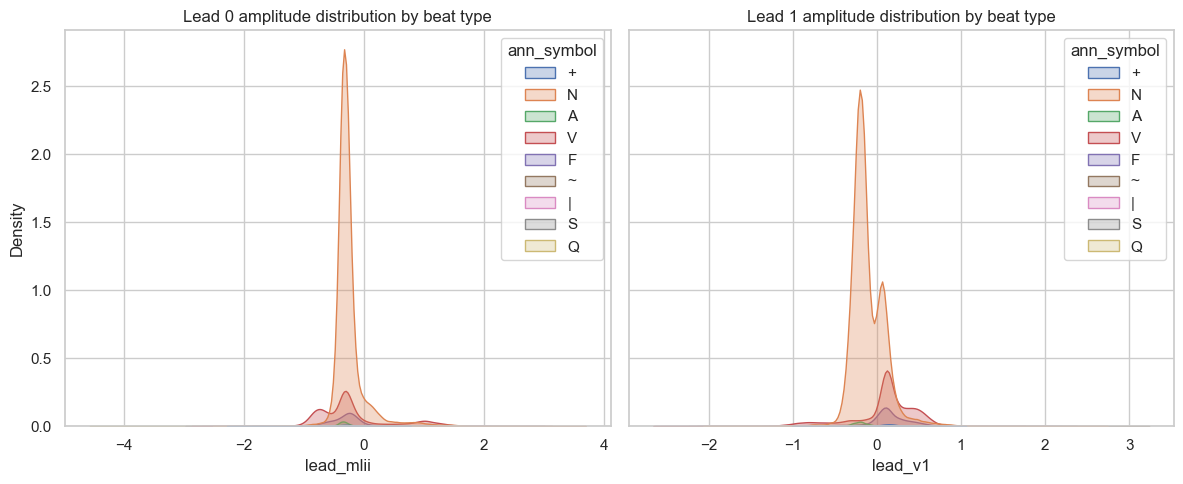

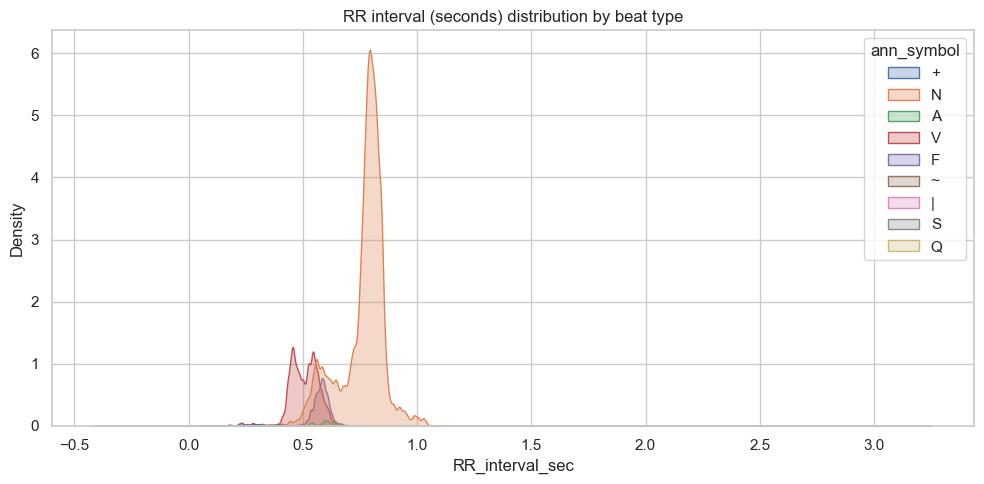

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style="whitegrid", context="notebook")

# --- 1️⃣ Distribution of Lead 0 and Lead 1 amplitudes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.kdeplot(data=df_all, x='lead_mlii', hue='ann_symbol', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("Lead 0 amplitude distribution by beat type")
sns.kdeplot(data=df_all, x='lead_v1', hue='ann_symbol', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title("Lead 1 amplitude distribution by beat type")
plt.tight_layout()
plt.show()

# --- 2️⃣ RR Interval Distributions (seconds) ---
if 'RR_interval_sec' in df_all.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.kdeplot(data=df_all, x='RR_interval_sec', hue='ann_symbol', fill=True, alpha=0.3)
    ax.set_title("RR interval (seconds) distribution by beat type")
    plt.tight_layout()
    plt.show()

#### Modeling

=== Classification Report ===
                 precision    recall  f1-score   support

     Normal (N)       1.00      1.00      1.00    297726
Ventricular (V)       1.00      1.00      1.00     65113

       accuracy                           1.00    362839
      macro avg       1.00      1.00      1.00    362839
   weighted avg       1.00      1.00      1.00    362839



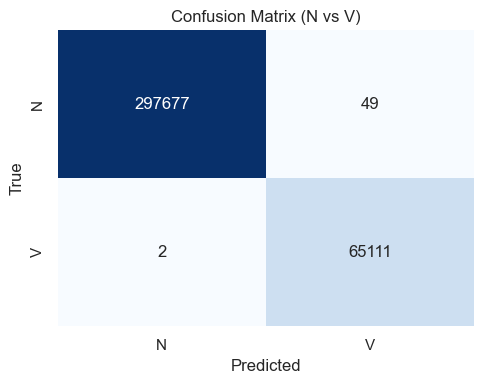

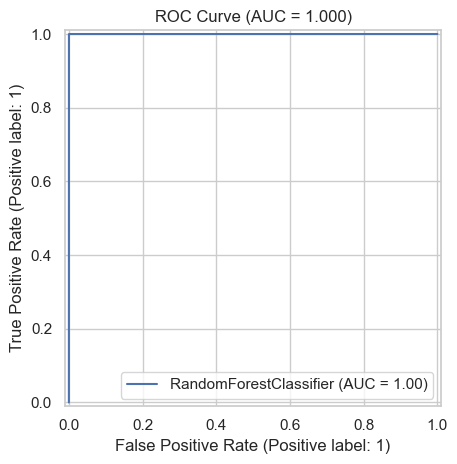

/var/folders/8j/b374spys48z0_v4q1g1pr4bc0000gn/T/ipykernel_69683/305362301.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


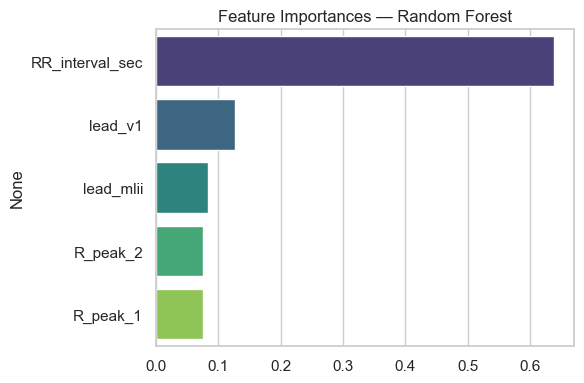

Mean CV AUC: 1.000 ± 0.000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- Filter to only N and V beats ---
df_model = df_all[df_all['ann_symbol'].isin(['N', 'V'])].copy()

# --- Feature selection ---
features = ['lead_mlii', 'lead_v1', 'RR_interval_sec', 'R_peak_1', 'R_peak_2']
X = df_model[features].fillna(0)
y = df_model['ann_symbol'].map({'N': 0, 'V': 1})  # binary target

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# --- Standardize continuous features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Random Forest (non-parametric) ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# --- Evaluation ---
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal (N)', 'Ventricular (V)']))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['N', 'V'], yticklabels=['N', 'V'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (N vs V)')
plt.tight_layout(); plt.show()

# --- ROC Curve ---
roc_auc = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_estimator(rf, X_test_scaled, y_test)
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout(); plt.show()

# --- Feature Importance ---
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importances — Random Forest")
plt.tight_layout(); plt.show()